In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import statsmodels.tsa.arima_process as arima_process

In [5]:
process = arima_process.ArmaProcess(ar =[1, -0.8], ma = [1])

In [6]:
process

ArmaProcess([1.0, -0.8], [1.0], nobs=100) at 0x29447ab8d70

In [14]:
z = process.generate_sample(nsample=100)

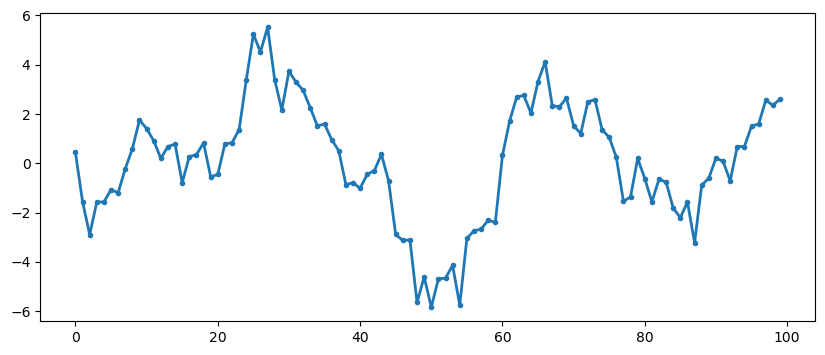

In [11]:
plt.figure(figsize=(10,4))
plt.plot(z, linewidth=2, marker='.')

In [15]:
acf = process.acf(lags=20)
acf

array([1.        , 0.8       , 0.64      , 0.512     , 0.4096    ,
       0.32768   , 0.262144  , 0.2097152 , 0.16777216, 0.13421773,
       0.10737418, 0.08589935, 0.06871948, 0.05497558, 0.04398047,
       0.03518437, 0.0281475 , 0.022518  , 0.0180144 , 0.01441152])

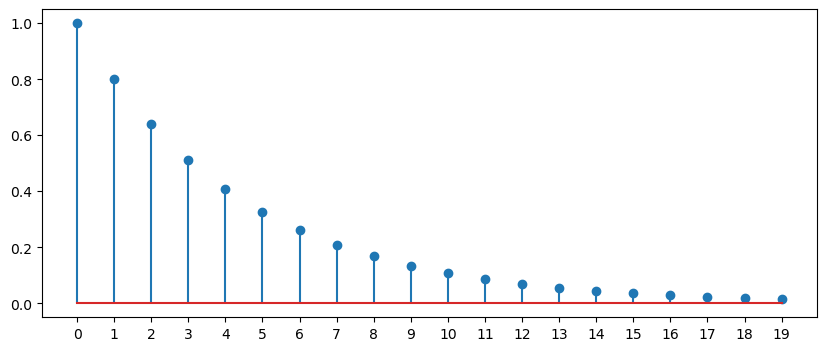

In [16]:
plt.figure(figsize=(10,4))
plt.stem(acf)
plt.xticks(ticks=range(len(acf)), labels=range(len(acf)))
plt.show()

In [17]:
import statsmodels.graphics.tsaplots as tsaplots

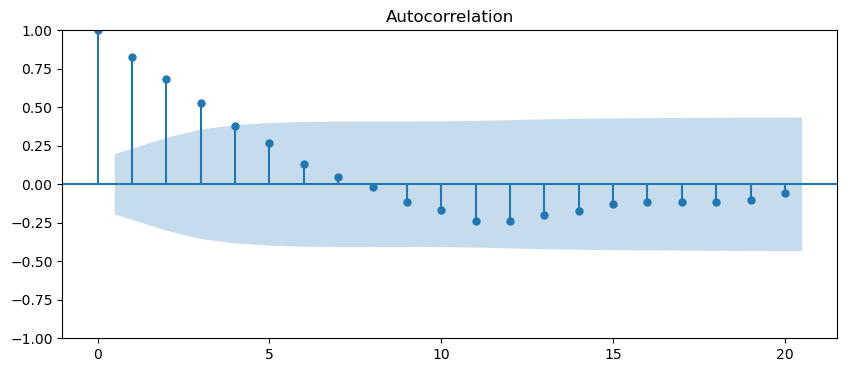

In [18]:
fig, x = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(z, lags=20, ax=x)
plt.show()

In [20]:
sunspots = pd.read_csv("Sunspots.csv")
sunspots

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7
...,...,...,...
3260,3260,2020-09-30,0.6
3261,3261,2020-10-31,14.4
3262,3262,2020-11-30,34.0
3263,3263,2020-12-31,21.8


In [22]:
pd.to_datetime(sunspots.loc[0, 'Date'])

Timestamp('1749-01-31 00:00:00')

In [24]:
sunspots = sunspots.set_index(pd.to_datetime(sunspots['Date']))
sunspots

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
Date,,,
1749-01-31,0,1749-01-31,96.7
1749-02-28,1,1749-02-28,104.3
1749-03-31,2,1749-03-31,116.7
1749-04-30,3,1749-04-30,92.8
1749-05-31,4,1749-05-31,141.7
...,...,...,...
2020-09-30,3260,2020-09-30,0.6
2020-10-31,3261,2020-10-31,14.4
2020-11-30,3262,2020-11-30,34.0


In [26]:
sunspots.drop(columns=['Unnamed: 0', 'Date'], inplace=True)
sunspots

,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0


In [ ]:
sunspots.rename(columns={'Monthly Mean Total Sunspot Number': 'values'}, inplace=True)
sunspots

,values
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0
